In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation

In [2]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [3]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink-experiment" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/blink-experiment-9.csv
2296
data/blink-experiment-15.csv
1986
data/blink-experiment-8.csv
1589
data/blink-experiment-12.csv
1900
data/blink-experiment-13.csv
1383
data/blink-experiment-11.csv
1407
data/blink-experiment-10.csv
1135
data/blink-experiment-6.csv
1432
data/blink-experiment-expose-points_1 (1).csv
1426
data/blink-experiment-7.csv
1923
data/blink-experiment-5.csv
1272
data/blink-experiment-expose-points_3.csv
2132
data/blink-experiment-expose-points_2.csv
1301
data/blink-experiment-expose-points_4.csv
1519
22701


In [4]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkColors"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


df_webgazer["isBlinkByCorrelation"] = df_webgazer.apply(
    lambda row: blinkCorrelations.isBlinkByCorrelation(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,leftEye,rightEye,dz,trial,experiment,file_name,isBlinkByEar,isBlinkByDistance,isBlinkColors,isBlinkByCorrelation
0,0,0,62,"{'noseX': 288.29, 'noseY': 313.05, 'topY': 190...","{'data': {'0': 84, '1': 62, '2': 42, '3': 255,...","{'data': {'0': 144, '1': 105, '2': 82, '3': 25...",51.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
1,0,0,81,"{'noseX': 289.14, 'noseY': 313.56, 'topY': 190...","{'data': {'0': 44, '1': 30, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 41, '2': 27, '3': 255,...",52.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,106,"{'noseX': 289.29, 'noseY': 313.86, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 43, '2': 26, '3': 255,...",53.01,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,142,"{'noseX': 288.98, 'noseY': 313.11, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 64, '1': 42, '2': 25, '3': 255,...",50.86,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,0,0,175,"{'noseX': 289.17, 'noseY': 313.61, 'topY': 190...","{'data': {'0': 48, '1': 32, '2': 16, '3': 255,...","{'data': {'0': 67, '1': 42, '2': 27, '3': 255,...",52.18,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,0,0,16670,"{'noseX': 332.29, 'noseY': 308.27, 'topY': 164...","{'data': {'0': 124, '1': 97, '2': 52, '3': 255...","{'data': {'0': 116, '1': 73, '2': 27, '3': 255...",41.95,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
491,0,0,16701,"{'noseX': 331.28, 'noseY': 308.62, 'topY': 165...","{'data': {'0': 128, '1': 100, '2': 58, '3': 25...","{'data': {'0': 121, '1': 77, '2': 32, '3': 255...",39.36,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
492,0,0,16732,"{'noseX': 331.85, 'noseY': 308.55, 'topY': 165...","{'data': {'0': 83, '1': 58, '2': 14, '3': 255,...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",40.61,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
493,0,0,16772,"{'noseX': 331.27, 'noseY': 309.03, 'topY': 165...","{'data': {'0': 127, '1': 101, '2': 54, '3': 25...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",39.11,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


In [12]:
 #resultados por participante blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby(['file_name'])['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear


,file_name,Blink_sample_ear_diff
0,data/blink-experiment-10.csv,59
1,data/blink-experiment-11.csv,52
2,data/blink-experiment-12.csv,81
3,data/blink-experiment-13.csv,51
4,data/blink-experiment-15.csv,80
5,data/blink-experiment-5.csv,52
6,data/blink-experiment-6.csv,49
7,data/blink-experiment-7.csv,54
8,data/blink-experiment-8.csv,53
9,data/blink-experiment-9.csv,52


In [7]:
 #resultados por participante blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear


,file_name,trial,Blink_sample_ear_diff
0,data/blink-experiment-10.csv,1,11
1,data/blink-experiment-10.csv,2,10
2,data/blink-experiment-10.csv,3,2
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,28
72,data/blink-experiment-expose-points_4.csv,1,13
73,data/blink-experiment-expose-points_4.csv,2,11
74,data/blink-experiment-expose-points_4.csv,3,9


In [13]:
 #resultados por participante blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby(['file_name'])['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,Blink_sample_dist_diff
0,data/blink-experiment-10.csv,57
1,data/blink-experiment-11.csv,52
2,data/blink-experiment-12.csv,91
3,data/blink-experiment-13.csv,49
4,data/blink-experiment-15.csv,62
5,data/blink-experiment-5.csv,66
6,data/blink-experiment-6.csv,48
7,data/blink-experiment-7.csv,54
8,data/blink-experiment-8.csv,54
9,data/blink-experiment-9.csv,52


In [8]:
 #resultados por participante blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,trial,Blink_sample_dist_diff
0,data/blink-experiment-10.csv,1,12
1,data/blink-experiment-10.csv,2,10
2,data/blink-experiment-10.csv,3,2
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,29
72,data/blink-experiment-expose-points_4.csv,1,14
73,data/blink-experiment-expose-points_4.csv,2,11
74,data/blink-experiment-expose-points_4.csv,3,11


In [14]:
 #resultados por participante blink color
df_webgazer["Blink_sample_col"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample_col_diff"] = (df_webgazer['Blink_sample_col'].shift(1)+1 == df_webgazer['Blink_sample_col'])


result_per_participant_col = df_webgazer.groupby(['file_name'])['Blink_sample_col_diff'].sum().reset_index()
result_per_participant_col

,file_name,Blink_sample_col_diff
0,data/blink-experiment-10.csv,70
1,data/blink-experiment-11.csv,51
2,data/blink-experiment-12.csv,7
3,data/blink-experiment-13.csv,73
4,data/blink-experiment-15.csv,72
5,data/blink-experiment-5.csv,29
6,data/blink-experiment-6.csv,51
7,data/blink-experiment-7.csv,86
8,data/blink-experiment-8.csv,96
9,data/blink-experiment-9.csv,78


In [9]:
 #resultados por participante blink color
df_webgazer["Blink_sample_col"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample_col_diff"] = (df_webgazer['Blink_sample_col'].shift(1)+1 == df_webgazer['Blink_sample_col'])


result_per_participant_col = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_col_diff'].sum().reset_index()
result_per_participant_col

,file_name,trial,Blink_sample_col_diff
0,data/blink-experiment-10.csv,1,9
1,data/blink-experiment-10.csv,2,13
2,data/blink-experiment-10.csv,3,6
3,data/blink-experiment-10.csv,4,15
4,data/blink-experiment-10.csv,5,18
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,7
72,data/blink-experiment-expose-points_4.csv,1,9
73,data/blink-experiment-expose-points_4.csv,2,15
74,data/blink-experiment-expose-points_4.csv,3,6


In [15]:
 #resultados por participante blink corr
df_webgazer["Blink_sample_corr"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample_corr_diff"] = (df_webgazer['Blink_sample_corr'].shift(1)+1 == df_webgazer['Blink_sample_corr'])


result_per_participant_corr = df_webgazer.groupby(['file_name'])['Blink_sample_corr_diff'].sum().reset_index()
result_per_participant_corr

,file_name,Blink_sample_corr_diff
0,data/blink-experiment-10.csv,35
1,data/blink-experiment-11.csv,61
2,data/blink-experiment-12.csv,46
3,data/blink-experiment-13.csv,69
4,data/blink-experiment-15.csv,88
5,data/blink-experiment-5.csv,32
6,data/blink-experiment-6.csv,50
7,data/blink-experiment-7.csv,38
8,data/blink-experiment-8.csv,69
9,data/blink-experiment-9.csv,88


In [10]:
 #resultados por participante blink corr
df_webgazer["Blink_sample_corr"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample_corr_diff"] = (df_webgazer['Blink_sample_corr'].shift(1)+1 == df_webgazer['Blink_sample_corr'])


result_per_participant_corr = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_corr_diff'].sum().reset_index()
result_per_participant_corr

,file_name,trial,Blink_sample_corr_diff
0,data/blink-experiment-10.csv,1,5
1,data/blink-experiment-10.csv,2,1
2,data/blink-experiment-10.csv,3,1
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,8
72,data/blink-experiment-expose-points_4.csv,1,11
73,data/blink-experiment-expose-points_4.csv,2,16
74,data/blink-experiment-expose-points_4.csv,3,5


In [28]:
result_per_participant_ear['error'] = np.where(
    result_per_participant_ear['trial'] == 3,
    np.abs(result_per_participant_ear['Blink_sample_ear_diff'] - 2),
    np.abs(result_per_participant_ear['Blink_sample_ear_diff'] - 10)
)
result_per_participant_ear = result_per_participant_ear.groupby('file_name')['error'].mean().reset_index()

result_per_participant_ear

,file_name,error
0,data/blink-experiment-10.csv,1.166667
1,data/blink-experiment-11.csv,0.333333
2,data/blink-experiment-12.csv,10.166667
3,data/blink-experiment-13.csv,0.166667
4,data/blink-experiment-15.csv,5.000000
5,data/blink-experiment-5.csv,0.666667
6,data/blink-experiment-6.csv,1.166667
7,data/blink-experiment-7.csv,0.333333
8,data/blink-experiment-8.csv,0.166667
9,data/blink-experiment-9.csv,0.000000


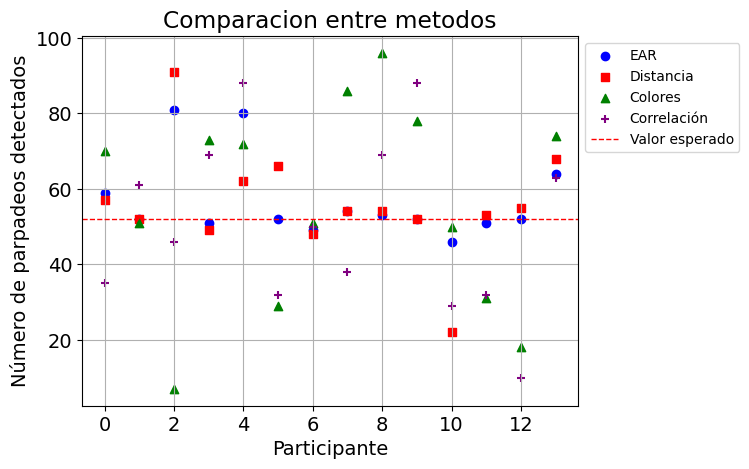

In [25]:
result_per_participant_ear
result_per_participant_dist
result_per_participant_col
result_per_participant_corr

plt.rcParams['font.size'] = 14

plt.scatter(list(range(14)), result_per_participant_ear['Blink_sample_ear_diff'], marker='o', color='blue', label='EAR')  # círculo
plt.scatter(list(range(14)), result_per_participant_dist['Blink_sample_dist_diff'], marker='s', color='red', label='Distancia')   # cuadrado
plt.scatter(list(range(14)), result_per_participant_col['Blink_sample_col_diff'], marker='^', color='green', label='Colores') # triángulo
plt.scatter(list(range(14)), result_per_participant_corr['Blink_sample_corr_diff'], marker='+', color='purple', label='Correlación') # cruz

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor esperado")

plt.xlabel('Participante')
plt.ylabel('Número de parpadeos detectados')
plt.title('Comparacion entre metodos')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)  # Leyenda fuera del gráfico
plt.grid(True)  # Activar la cuadrícula

# Mostrar
plt.show()


In [37]:
result_per_participant_ear['metodo'] = 'ear'
result_per_participant_ear['Blink_sample_diff'] = result_per_participant_ear['Blink_sample_ear_diff']
result_per_participant_dist['metodo'] = 'dist'
result_per_participant_dist['Blink_sample_diff'] = result_per_participant_dist['Blink_sample_dist_diff']
result_per_participant_col['metodo'] = 'col'
result_per_participant_col['Blink_sample_diff'] = result_per_participant_col['Blink_sample_col_diff']
result_per_participant_corr['metodo'] = 'corr'
result_per_participant_corr['Blink_sample_diff'] = result_per_participant_corr['Blink_sample_corr_diff']

combined_df = pd.concat([result_per_participant_ear, result_per_participant_dist, result_per_participant_col, result_per_participant_corr])
result_df = combined_df[['Blink_sample_diff', 'metodo']]
result_df
##result_df["error"] = result_df['Blink_sample_diff'] - 50

##result_df.to_csv('resultado_final.csv', index=False)



,Blink_sample_diff,metodo
0,59,ear
1,52,ear
2,81,ear
3,51,ear
4,80,ear
5,52,ear
6,49,ear
7,54,ear
8,53,ear
9,52,ear


In [38]:

combined_df["error"] = abs(combined_df['Blink_sample_diff'] - 50)

result_df = combined_df[['Blink_sample_diff', 'error', 'metodo']]
##print(result_df)

agrupado = result_df.groupby('metodo')['error'].agg(['mean', 'std'])

print(agrupado)


             mean        std
metodo                      
col     22.571429  14.489860
corr    19.000000  12.152872
dist    10.357143  11.816593
ear      7.571429  10.360534


In [40]:


agrupado = combined_df.groupby('metodo')['Blink_sample_diff'].agg(['mean', 'std'])

print(agrupado)

             mean        std
metodo                      
col     56.142857  26.795112
corr    50.714286  23.149775
dist    55.928571  14.741174
ear     56.857143  10.882994


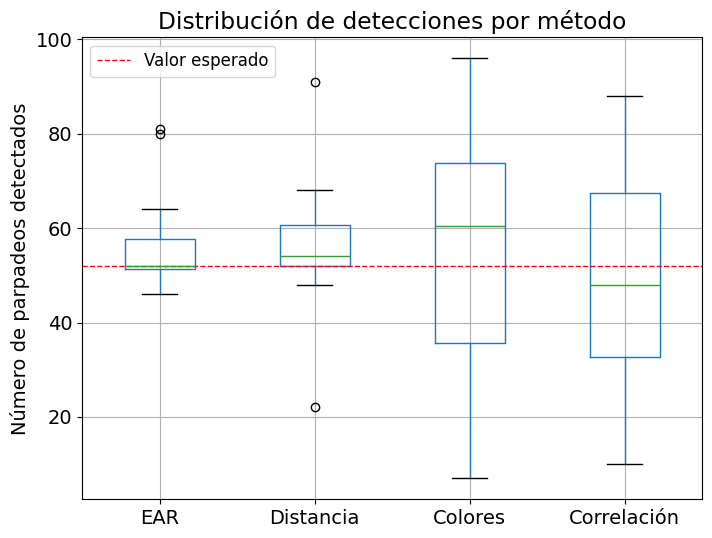

In [33]:

# Unimos los datos en un único DataFrame para facilitar el boxplot
data = pd.DataFrame({
    'EAR': result_per_participant_ear['Blink_sample_ear_diff'],
    'Distancia': result_per_participant_dist['Blink_sample_dist_diff'],
    'Colores': result_per_participant_col['Blink_sample_col_diff'],
    'Correlación': result_per_participant_corr['Blink_sample_corr_diff']
})

plt.rcParams['font.size'] = 14

# Generar boxplot
ax = data.boxplot(column=['EAR', 'Distancia', 'Colores', 'Correlación'],
                  grid=True, figsize=(8,6))

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor esperado")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=12)  # Leyenda fuera del gráfico

plt.ylabel('Número de parpadeos detectados')
plt.title('Distribución de detecciones por método')
plt.show()


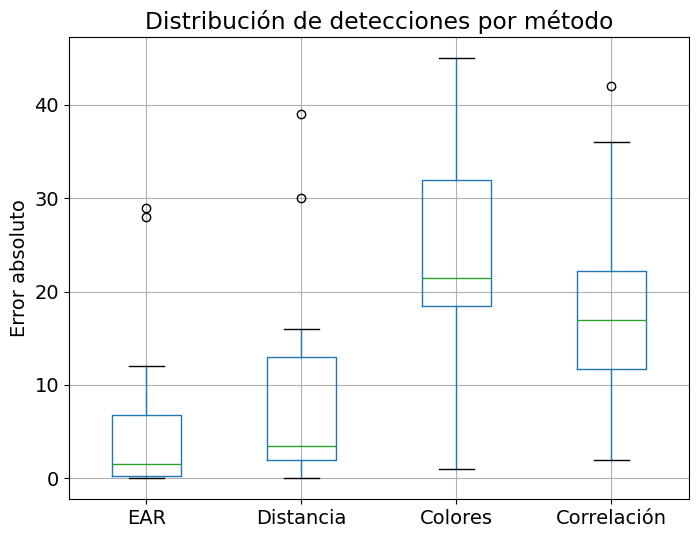

In [28]:
#Boxplot con error en vez de cant de blinks
valor_esperado = 52

data = pd.DataFrame({
    'EAR': abs(result_per_participant_ear['Blink_sample_ear_diff'] - valor_esperado),
    'Distancia': abs(result_per_participant_dist['Blink_sample_dist_diff'] - valor_esperado),
    'Colores': abs(result_per_participant_col['Blink_sample_col_diff'] - valor_esperado),
    'Correlación': abs(result_per_participant_corr['Blink_sample_corr_diff'] - valor_esperado)
})

plt.rcParams['font.size'] = 14

# Generar boxplot
ax = data.boxplot(column=['EAR', 'Distancia', 'Colores', 'Correlación'],
                  grid=True, figsize=(8,6))

plt.ylabel('Error absoluto')
plt.title('Distribución de detecciones por método')
plt.show()